# XGBoost Phishing URL Detection - Training Notebook
## Focus: Minimizing False Positive Rate (FPR) with a Robust, Real-World-Like Class Ratio

This notebook trains an **XGBClassifier** to detect phishing URLs with a strong emphasis on minimizing False Positives (classifying legitimate sites as phishing), while keeping high recall on real phishing.

### Dataset Strategy (rebalanced):
- **Benign (majority class)**: all benign URLs + a large curated "hard safe" set (complex but legitimate).
- **Phishing (minority class)**: **downsampled** from the raw phishing pool so the class ratio reflects the real world, where legitimate traffic dominates.
- This shift **reduces FPR** and **forces the model to learn what "safe" really looks like**.

### Robustness upgrades for XGBoost:
- Lower `max_depth`, higher `min_child_weight`, `gamma > 0` to prevent overfitting.
- `subsample`, `colsample_bytree`, `colsample_bylevel`, `colsample_bynode` for stochastic training.
- Stronger L1/L2 regularization (`reg_alpha`, `reg_lambda`).
- `early_stopping_rounds=100` on validation logloss.
- `scale_pos_weight` tuned for the new benign-heavy ratio.

### FPR target:
- **< 5%** (accepted operating budget). Threshold is tuned on the validation set, then verified on the held-out test set.

In [2]:
import os
import sys
import importlib.util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# --- Dynamically find project root ---
current_dir = os.getcwd()
project_root = current_dir
while not os.path.exists(os.path.join(project_root, 'data')):
    project_root = os.path.dirname(project_root)
    if len(project_root) < 3:
        raise Exception("Could not find project root.")

INPUT_FILE = os.path.join(project_root, 'data', 'datasets', 'url_features_dataset.csv')
FEATURE_SCRIPT = os.path.join(project_root, 'src', 'features', 'extract_url_features.py')
MODEL_PATH = os.path.join(project_root, 'src', 'models', 'saved_models', 'url_xgboost.pkl')

# Ensure save directory exists
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

print(f"Project Root: {project_root}")
print(f"Input File:   {INPUT_FILE}")
print(f"Model Path:   {MODEL_PATH}")

Project Root: d:\project-3
Input File:   d:\project-3\data\datasets\url_features_dataset.csv
Model Path:   d:\project-3\src\models\saved_models\url_xgboost.pkl


In [3]:
# --- Load feature extraction module ---
if not os.path.exists(FEATURE_SCRIPT):
    print(f"ERROR: Feature script not found at {FEATURE_SCRIPT}")
else:
    spec = importlib.util.spec_from_file_location("extract_module", FEATURE_SCRIPT)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    extract_features = module.extract_features
    print("Success: 'extract_features' function loaded.")

Success: 'extract_features' function loaded.


In [4]:
# --- Complex SAFE URLs the model often misclassifies ---
# These legitimate URLs have complex structures (subdomains, long paths, query params, login/secure keywords)
# Expanded set to explicitly teach the model that "long + login/secure/verify/account" != phishing
hard_safe_urls = [
    # Google Services
    "https://gemini.google.com/app",
    "https://docs.google.com/document/d/1abc123xyz/edit?usp=sharing",
    "https://drive.google.com/file/d/1234567890/view",
    "https://mail.google.com/mail/u/0/#inbox",
    "https://accounts.google.com/signin/v2/identifier",
    "https://calendar.google.com/calendar/u/0/r",
    "https://meet.google.com/abc-defg-hij",
    "https://cloud.google.com/products/compute",
    "https://console.cloud.google.com/home/dashboard",
    "https://play.google.com/store/apps/details?id=com.example",
    "https://news.google.com/topstories?hl=en",
    "https://translate.google.com/?sl=en&tl=vi",
    "https://maps.google.com/maps?q=hanoi",
    "https://photos.google.com/album/abc123",
    "https://colab.research.google.com/drive/1xyz",
    # Microsoft Services
    "https://portal.azure.com/#create/Microsoft.VirtualMachine",
    "https://outlook.live.com/mail/0/inbox",
    "https://onedrive.live.com/?id=root",
    "https://login.microsoftonline.com/common/oauth2/authorize",
    "https://teams.microsoft.com/_#/conversations",
    "https://office.com/launch/word",
    "https://sharepoint.com/sites/company",
    "https://visualstudio.microsoft.com/downloads/",
    "https://learn.microsoft.com/en-us/docs",
    "https://dev.azure.com/organization/project",
    # Amazon Services
    "https://www.amazon.com/dp/B09G9FPHY6/ref=cm_sw_r",
    "https://aws.amazon.com/console/",
    "https://console.aws.amazon.com/ec2/v2/home",
    "https://s3.console.aws.amazon.com/s3/buckets",
    "https://signin.aws.amazon.com/signin",
    "https://prime.amazon.com/",
    "https://music.amazon.com/albums/B08XYZ",
    # Social Media & Entertainment
    "https://www.facebook.com/profile.php?id=100000",
    "https://m.facebook.com/login/?next=https%3A%2F%2Fm.facebook.com",
    "https://www.instagram.com/accounts/login/",
    "https://twitter.com/i/flow/login",
    "https://x.com/home",
    "https://www.linkedin.com/in/username/",
    "https://www.youtube.com/watch?v=dQw4w9WgXcQ&list=PLxyz",
    "https://studio.youtube.com/channel/UCxyz",
    "https://www.tiktok.com/@username/video/1234567890",
    "https://www.reddit.com/r/programming/comments/abc123",
    "https://discord.com/channels/123456789/987654321",
    "https://www.netflix.com/watch/80186799",
    "https://open.spotify.com/track/4iV5W9uYEdYUVa79Axb7Rh",
    # Developer & Tech
    "https://github.com/microsoft/vscode/blob/main/README.md",
    "https://stackoverflow.com/questions/12345678/how-to-fix",
    "https://gitlab.com/user/repo/-/merge_requests/1",
    "https://bitbucket.org/workspace/repo/src/main/",
    "https://npmjs.com/package/react",
    "https://pypi.org/project/tensorflow/",
    "https://hub.docker.com/_/python",
    "https://vercel.com/dashboard",
    "https://app.netlify.com/sites/mysite",
    "https://heroku.com/apps/myapp",
    "https://railway.app/project/abc123",
    # Finance & Business (legitimate)
    "https://www.paypal.com/myaccount/summary",
    "https://www.chase.com/personal/checking",
    "https://www.bankofamerica.com/online-banking/",
    "https://www.wellsfargo.com/biz/",
    "https://www.vanguard.com/us/LogonEmailAddress",
    "https://robinhood.com/account",
    # E-commerce & Services
    "https://www.ebay.com/itm/123456789012",
    "https://www.etsy.com/listing/1234567890",
    "https://www.alibaba.com/product-detail/xyz",
    "https://www.shopify.com/admin",
    "https://www.wordpress.com/post/mysite/123",
    "https://medium.com/@author/article-title-abc123",
    "https://www.notion.so/workspace/page-id",
    "https://trello.com/b/abc123/board-name",
    "https://slack.com/workspace/messages/channel",
    "https://zoom.us/j/1234567890?pwd=xyz",
    # Education & Reference
    "https://www.coursera.org/learn/machine-learning",
    "https://www.udemy.com/course/python-bootcamp/",
    "https://www.khanacademy.org/computing/computer-science",
    "https://en.wikipedia.org/wiki/Phishing",
    "https://scholar.google.com/citations?user=xyz",
    # Vietnamese sites
    "https://vnexpress.net/kinh-doanh",
    "https://shopee.vn/product/123456789",
    "https://tiki.vn/san-pham/abc-p12345",
    "https://lazada.vn/products/xyz-i123456.html",
    "https://momo.vn/payment",
    "https://vietcombank.com.vn/",
    "https://techcombank.com.vn/personal",
    # --- Extra "login / secure / verify / account" legit URLs (often misclassified) ---
    "https://accounts.google.com/v3/signin/identifier?continue=https%3A%2F%2Fmail.google.com",
    "https://accounts.google.com/ServiceLogin?service=youtube&hl=en",
    "https://signin.ebay.com/ws/eBayISAPI.dll?SignIn",
    "https://secure.bankofamerica.com/login/sign-in/signOnV2Screen.go",
    "https://secure.chase.com/web/auth/dashboard",
    "https://secure.wellsfargo.com/login?origin=cob",
    "https://secure.citi.com/US/JRS/pands/detail.do",
    "https://secure.adobe.com/account.html",
    "https://login.live.com/login.srf?wa=wsignin1.0",
    "https://login.yahoo.com/?.src=ym&.intl=us",
    "https://login.salesforce.com/?ec=302&startURL=%2Fhome",
    "https://account.microsoft.com/account/Account",
    "https://account.apple.com/account/manage",
    "https://account.samsung.com/accounts/v1/MBR/signInGate",
    "https://account.adobe.com/security",
    "https://account.netflix.com/security",
    "https://account.proton.me/u/0/mail/dashboard",
    "https://myaccount.google.com/security?hl=en",
    "https://myaccount.nytimes.com/auth/login",
    "https://my.playstation.com/profile",
    "https://id.atlassian.com/login?continue=https%3A%2F%2Ftrello.com",
    "https://auth.openai.com/login?callback=%2Fchat",
    "https://auth0.com/docs/authenticate/login",
    "https://verify.docusign.com/verification",
    "https://www.paypal.com/signin?returnUri=https%3A%2F%2Fwww.paypal.com%2Fmyaccount%2Fsummary",
    "https://www.paypal.com/webapps/mpp/security/secure-shopping",
    "https://www.dropbox.com/account/security",
    "https://www.icloud.com/settings/accountsecurity",
    "https://appleid.apple.com/sign-in?response_type=code&client_id=com.apple",
    "https://id.me/verify",
    "https://www.irs.gov/payments/view-your-tax-account",
    "https://www.ssa.gov/myaccount/",
    "https://www.usps.com/manage/track-package.htm?tLabels=9400111202555842761234",
    # --- Long legitimate URLs with many query params / tokens ---
    "https://www.amazon.com/s?k=wireless+headphones&crid=2M096C61O4MLT&sprefix=wireles&ref=nb_sb_noss_2",
    "https://www.amazon.com/gp/buy/addressselect/handlers/display.html?hasWorkingJavascript=1",
    "https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=&cad=rja&uact=8&url=https%3A%2F%2Fen.wikipedia.org%2Fwiki%2FPython",
    "https://www.youtube.com/results?search_query=machine+learning+tutorial&sp=EgIQAQ%253D%253D",
    "https://www.linkedin.com/feed/update/urn:li:activity:7152193821234567890/",
    "https://github.com/pytorch/pytorch/pull/123456/files#diff-abcdef1234567890",
    "https://github.com/kubernetes/kubernetes/blob/master/cmd/kube-apiserver/app/server.go",
    "https://stackoverflow.com/questions/tagged/python?tab=votes&pagesize=50",
    "https://gitlab.com/gitlab-org/gitlab/-/issues/123456?sort=created_date&state=opened",
    "https://www.bing.com/search?q=xgboost+classifier&qs=n&form=QBRE&sp=-1",
    "https://duckduckgo.com/?q=phishing+detection+xgboost&t=h_&ia=web",
    "https://chat.openai.com/share/abcd1234-5678-90ef-ghij-klmnopqrstuv",
    "https://huggingface.co/datasets/squad/viewer/default/train?row=0",
    "https://huggingface.co/bert-base-uncased/commit/abc123def456789",
    "https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/keras/classification.ipynb",
    "https://www.kaggle.com/competitions/titanic/data?select=train.csv",
    "https://www.kaggle.com/code/alexisbcook/titanic-tutorial/notebook",
    # --- Education / government / research with complex paths ---
    "https://canvas.instructure.com/courses/1234567/assignments/98765432",
    "https://moodle.example.edu/mod/quiz/view.php?id=1234567",
    "https://www.coursera.org/programs/university-of-london-bachelor-s/browse?productTypeDescription=Courses",
    "https://www.edx.org/learn/computer-science/harvard-university-cs50-s-introduction-to-computer-science",
    "https://arxiv.org/pdf/2301.12345v2.pdf",
    "https://pubmed.ncbi.nlm.nih.gov/12345678/",
    "https://ieeexplore.ieee.org/document/9876543",
    "https://dl.acm.org/doi/abs/10.1145/1234567.8901234",
    # --- E-commerce / banking with verify/account/password wording ---
    "https://help.shopify.com/en/manual/your-account/account-security",
    "https://help.instagram.com/566810106808145",
    "https://www.ebay.com/help/account/protecting-account/recognizing-phishing-emails-websites",
    "https://www.paypal.com/us/smarthelp/article/how-do-i-recognize-a-phishing-email-faq3267",
    "https://support.google.com/accounts/answer/6401754?hl=en",
    "https://support.apple.com/en-us/HT204145",
    "https://support.microsoft.com/en-us/account-billing/how-to-sign-in-to-your-microsoft-account",
    # --- Payment / checkout URLs (legitimate but often flagged) ---
    "https://checkout.stripe.com/c/pay/cs_test_abc1234567890",
    "https://buy.stripe.com/test_4gw5nR3iY9dM4zCaEE",
    "https://pay.google.com/gp/w/u/0/home/signup",
    "https://checkout.shopify.com/checkouts/abc-1234-5678/shipping",
    "https://www.paypal.com/checkoutnow?token=EC-1234567890ABCDEF",
    "https://www.amazon.com/gp/cart/view.html?ref_=nav_cart",
    # --- URL-shortener-looking legit redirects on big platforms ---
    "https://t.co/aBcDeFgHiJ",
    "https://lnkd.in/eXaMpLe123",
    "https://youtu.be/dQw4w9WgXcQ?si=abcd1234efgh5678",
    "https://forms.gle/abc123xyz456",
    "https://goo.gl/maps/abcDEF123",
    # --- International legit URLs ---
    "https://www.amazon.co.jp/dp/B08N5WRWNW?ref=ppx_yo2_dt_b_product_details",
    "https://www.ebay.de/itm/264567890123?hash=item3d9abc1234",
    "https://www.rakuten.co.jp/category/home/?scid=wi_iss_gnavi_cat_home_9",
    "https://www.amazon.in/dp/B0ABCDEFGH/?_encoding=UTF8&tag=in-21",
    "https://www.mercadolibre.com.br/ofertas#filters=category%3DME1055",
    # --- Extra Vietnamese legit sites ---
    "https://shopee.vn/user/account/profile",
    "https://shopee.vn/buyer/123456789/order",
    "https://tiki.vn/khuyen-mai/dien-thoai-may-tinh-bang",
    "https://www.lazada.vn/shop/official-stores/",
    "https://www.sendo.vn/san-pham-dien-tu.html",
    "https://www.thegioididong.com/dtdd-samsung",
    "https://fptshop.com.vn/may-tinh-xach-tay",
    "https://fahasa.com/sach-trong-nuoc/van-hoc-trong-nuoc.html",
    "https://vieon.vn/phim-bo-viet-nam",
    "https://fptplay.vn/xem-truyen-hinh/vtv1-hd",
    "https://www.bidv.com.vn/vn/ca-nhan/ngan-hang-dien-tu",
    "https://www.mbbank.com.vn/personal",
    "https://www.acb.com.vn/wps/portal/vn/acb-ca-nhan",
    "https://www.agribank.com.vn/vn/ca-nhan",
    "https://vietinbank.vn/web/home/vn/personal/",
    "https://www.vietcombank.com.vn/vi-VN/KHCN/Dich-vu-the",
    # --- Admin / IT / SaaS consoles with token-like strings ---
    "https://dashboard.cloudflare.com/login",
    "https://app.datadoghq.com/dashboard/abc-123-xyz/incidents",
    "https://sentry.io/organizations/myorg/issues/1234567890/",
    "https://app.pagerduty.com/incidents/PABC123",
    "https://grafana.example.com/d/abcdef1234567/my-dashboard",
    "https://app.snowflake.com/organization/account/#/data/databases",
    "https://databricks.com/login",
    "https://login.okta.com/login/login.htm?fromURI=%2Fapp%2Fmy-app",
    "https://myorg.onelogin.com/portal",
    "https://app.1password.com/home",
    "https://vault.bitwarden.com/#/login",
    # --- Streaming / media with long tokens ---
    "https://www.netflix.com/title/80100172",
    "https://www.netflix.com/browse/genre/83?so=su",
    "https://www.hulu.com/watch/abc123-def456",
    "https://www.disneyplus.com/video/abcdef12-3456-7890-abcd-ef1234567890",
    "https://tv.apple.com/us/show/ted-lasso/umc.cmc.vtoh0mn0xn7t3c643xqonfzy",
    # --- Developer cloud consoles (often long / token-ish) ---
    "https://console.cloud.google.com/compute/instances?project=my-project-123456",
    "https://console.aws.amazon.com/cloudformation/home?region=us-west-2#/stacks",
    "https://portal.azure.com/#@mytenant.onmicrosoft.com/resource/subscriptions/00000000-0000-0000-0000-000000000000/resourceGroups/my-rg/overview",
    "https://dashboard.digitalocean.com/projects/abc123/resources",
    "https://cloud.linode.com/linodes?page=1",
    "https://manage.auth0.com/dashboard/us/myorg/applications",
]

df_hard = pd.DataFrame({'url': hard_safe_urls, 'label': 0})
print(f"Added {len(hard_safe_urls)} complex safe URLs to training data")

Added 203 complex safe URLs to training data


In [5]:
# --- Load and REBALANCE the dataset ---
# Strategy:
#   * Phishing (minority): DOWNSAMPLE to ~10k. Keeps the hardest / most representative samples.
#   * Benign   (majority): KEEP ALL + hard_safe_urls + stratified upsampling of
#                          rare benign "looks-suspicious" patterns (login / secure / verify / account / long URLs).
# Resulting ratio roughly reflects the real-world Internet (benign >> phishing),
# which naturally lowers False Positive Rate.
df_original = pd.read_csv(INPUT_FILE)
print(f"Original dataset loaded: {len(df_original):,} rows")
print(f"  Phishing (1): {(df_original['label']==1).sum():,}")
print(f"  Benign   (0): {(df_original['label']==0).sum():,}")

# --- 1) Downsample phishing ---
TARGET_PHISHING = 10000  # was 15k. Removing ~5k random phishing reduces over-fitting to noisy PhishTank samples.
df_phish = df_original[df_original['label'] == 1]
df_benign_orig = df_original[df_original['label'] == 0]

if len(df_phish) > TARGET_PHISHING:
    df_phish = df_phish.sample(n=TARGET_PHISHING, random_state=42)
    print(f"\n  Phishing downsampled -> {len(df_phish):,}")
else:
    print(f"\n  Phishing already <= target ({len(df_phish):,})")

# --- 2) Build augmented benign pool ---
print("\nExtracting features for hard safe URLs...")
df_hard_features = extract_features(df_hard)

# Oversample "hard" benign patterns (they're rare vs. the whole benign pool,
# so we duplicate them a few times to raise their weight during training).
HARD_OVERSAMPLE = 5
df_hard_oversampled = pd.concat([df_hard_features] * HARD_OVERSAMPLE, ignore_index=True)
print(f"  Hard safe URLs oversampled x{HARD_OVERSAMPLE} -> {len(df_hard_oversampled):,}")

# Also oversample the "suspicious-looking" legit URLs already in df_original
# (those that contain login/secure/verify/account/signin/auth keywords).
url_lower = df_benign_orig['url'].astype(str).str.lower()
suspicious_mask = url_lower.str.contains(
    r'(login|secure|verify|account|signin|sign-in|auth|password|wallet)',
    regex=True, na=False
)
df_benign_suspicious = df_benign_orig[suspicious_mask]
print(f"  Suspicious-looking legit URLs found: {len(df_benign_suspicious):,}")

SUSP_OVERSAMPLE = 2  # duplicate to push the model toward "this pattern is still benign"
df_benign_suspicious_boost = pd.concat([df_benign_suspicious] * (SUSP_OVERSAMPLE - 1), ignore_index=True)

# Final benign pool = all original benign + hard safe (oversampled) + suspicious-looking boost
df_benign_final = pd.concat(
    [df_benign_orig, df_hard_oversampled, df_benign_suspicious_boost],
    ignore_index=True
).fillna(0)

# --- 3) Combine, shuffle ---
df_final = pd.concat([df_phish, df_benign_final], ignore_index=True).fillna(0)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

n_phish = int((df_final['label'] == 1).sum())
n_benign = int((df_final['label'] == 0).sum())
print(f"\nFinal dataset: {len(df_final):,} rows")
print(f"  Phishing (1): {n_phish:,}   ({n_phish/len(df_final)*100:.1f}%)")
print(f"  Benign   (0): {n_benign:,}   ({n_benign/len(df_final)*100:.1f}%)")
print(f"  Ratio benign:phishing = {n_benign/max(n_phish,1):.2f}:1")

Original dataset loaded: 30,000 rows
  Phishing (1): 15,000
  Benign   (0): 15,000

  Phishing downsampled -> 10,000

Extracting features for hard safe URLs...

  URL FEATURE EXTRACTION (Advanced)
  Processing 203 URLs...
[1/9] Parsing URLs...
[2/9] Extracting length features...
[3/9] Extracting count features...
[4/9] Extracting domain analysis features...
[5/9] Extracting keyword features...
[6/9] Extracting protocol & structure features...
[7/9] Extracting TLD reputation features...
[8/9] Extracting domain linguistic features...
[9/9] Extracting path structure features...

  EXTRACTION COMPLETE
  84 features extracted for 203 URLs
  Time elapsed: 0.2s
  Hard safe URLs oversampled x5 -> 1,015
  Suspicious-looking legit URLs found: 1,001

Final dataset: 27,016 rows
  Phishing (1): 10,000   (37.0%)
  Benign   (0): 17,016   (63.0%)
  Ratio benign:phishing = 1.70:1


C:\Users\hungc\AppData\Local\Temp\ipykernel_49244\99472709.py:37: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  suspicious_mask = url_lower.str.contains(


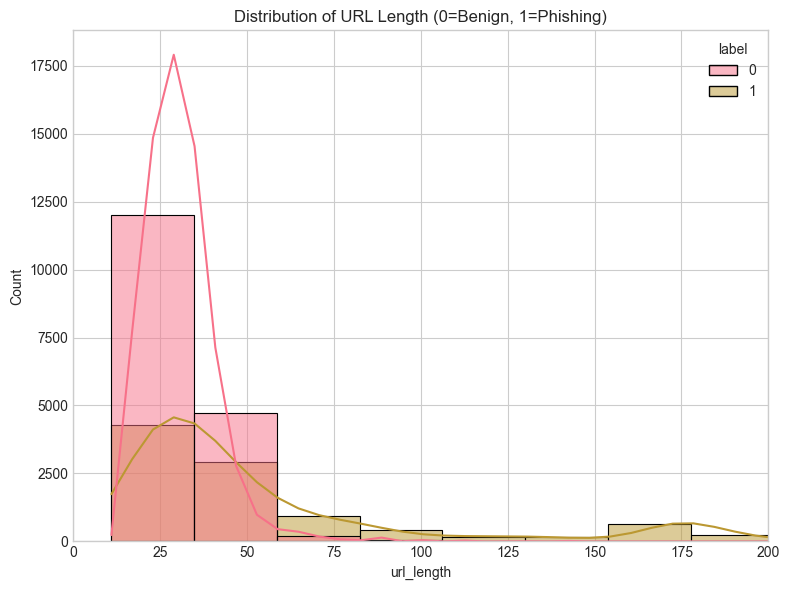

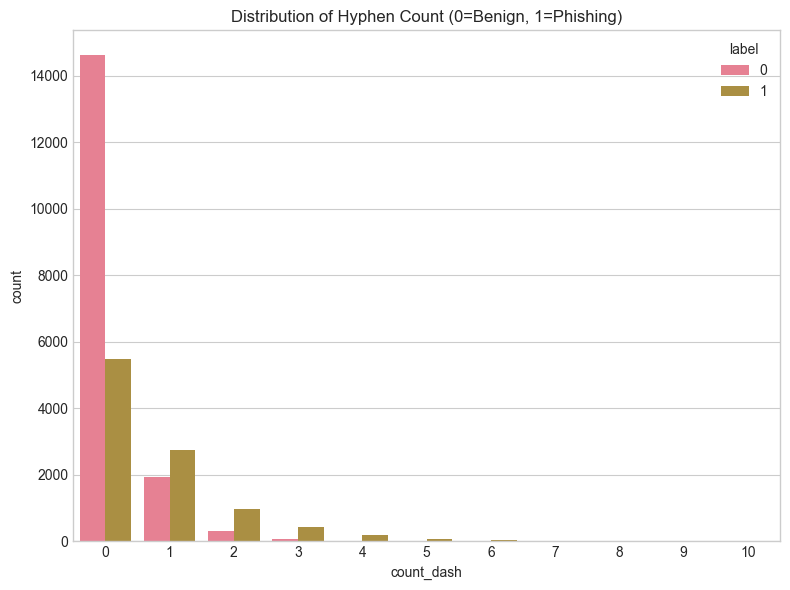

: 

In [ ]:
# --- ADDED: Distribution of URL length and Hyphen count ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. URL Length Distribution
plt.figure(figsize=(8, 6))
sns.histplot(data=df_final, x='url_length', hue='label', bins=50, kde=True)
plt.title('Distribution of URL Length (0=Benign, 1=Phishing)')
plt.xlim(0, 200) # Cap at 200 to avoid extreme outliers skewing the plot
plt.tight_layout()
plt.show()

# 2. Hyphen Count Distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_final, x='count_dash', hue='label')
plt.title('Distribution of Hyphen Count (0=Benign, 1=Phishing)')
plt.xlim(-0.5, 10.5) # Cap to show meaningful differences
plt.tight_layout()
plt.show()


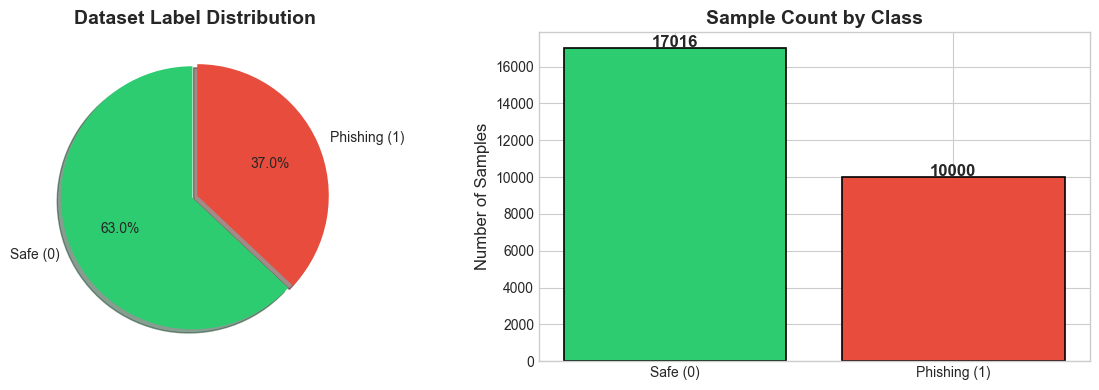

In [5]:
# --- Dataset Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# FIX: Thêm .sort_index() để luôn giữ (0) trước, (1) sau bất chấp số lượng
label_counts = df_final['label'].value_counts().sort_index()
labels_viz = ['Safe (0)', 'Phishing (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(label_counts, labels=labels_viz, autopct='%1.1f%%', colors=colors,
            explode=(0.02, 0.02), shadow=True, startangle=90)
axes[0].set_title('Dataset Label Distribution', fontsize=14, fontweight='bold')

bars = axes[1].bar(labels_viz, label_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Sample Count by Class', fontsize=14, fontweight='bold')
for bar, count in zip(bars, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


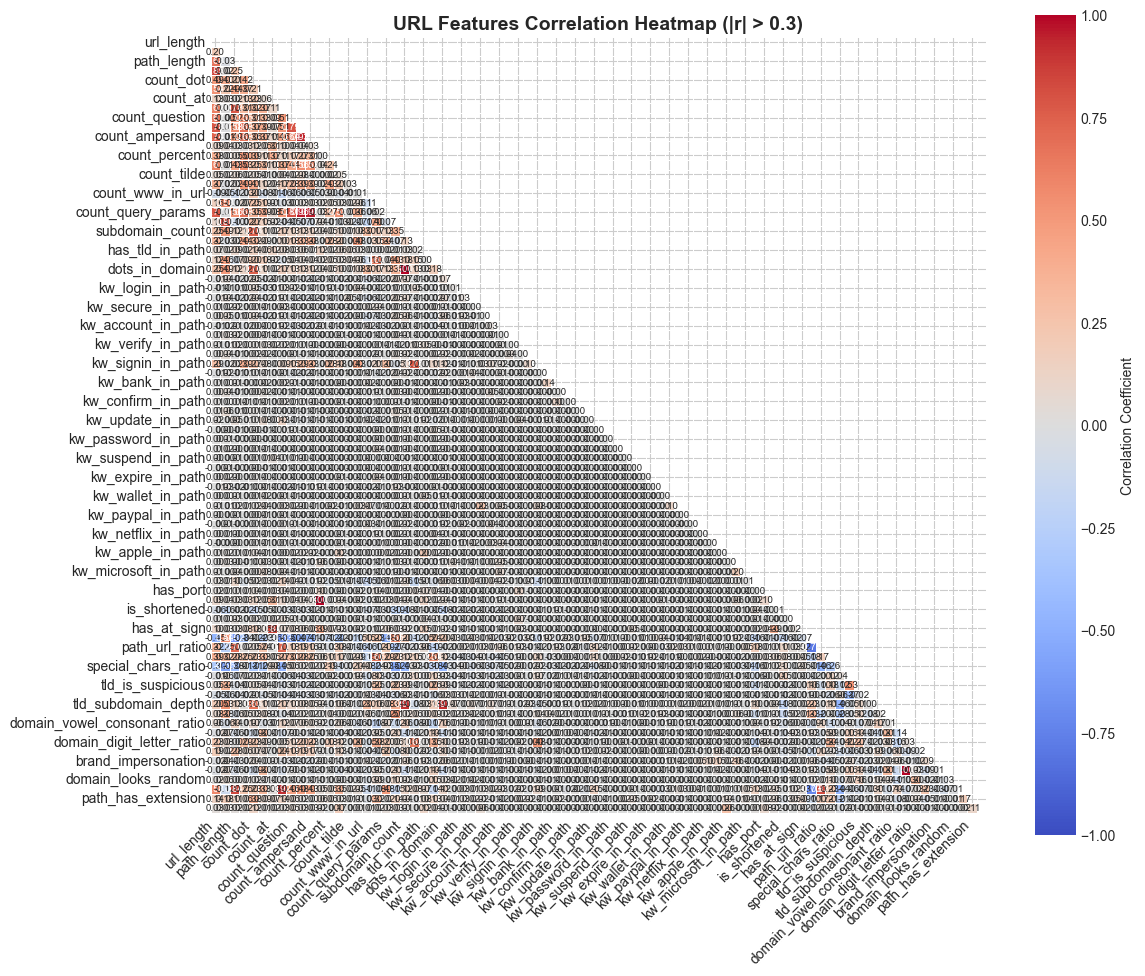


HIGH CORRELATIONS (|r| > 0.7):
  url_length <-> query_length: 0.849
  url_length <-> count_equal: 0.784
  url_length <-> count_ampersand: 0.737
  url_length <-> count_query_params: 0.774
  hostname_length <-> domain_entropy: 0.804
  path_length <-> count_slash: 0.780
  path_length <-> path_depth: 0.836
  count_dot <-> subdomain_count: 0.757
  count_dot <-> dots_in_domain: 0.757
  count_at <-> has_at_sign: 0.843
  count_slash <-> path_url_ratio: 0.707
  count_slash <-> path_depth: 0.917
  count_question <-> count_equal: 0.789
  count_question <-> count_query_params: 0.812
  count_equal <-> count_ampersand: 0.930
  count_equal <-> count_query_params: 0.959
  count_ampersand <-> count_query_params: 0.958
  count_hash <-> has_fragment: 1.000
  subdomain_count <-> dots_in_domain: 1.000
  subdomain_count <-> tld_subdomain_depth: 0.913
  is_ip_address <-> kw_signin_in_path: 0.758
  dots_in_domain <-> tld_subdomain_depth: 0.913
  hostname_url_ratio <-> path_url_ratio: -0.792
  hostname_url_ra

In [6]:
# --- Correlation Heatmap (Top features only for readability) ---
feature_cols = df_final.drop(['url', 'label'], axis=1).columns
correlation_matrix = df_final[feature_cols].corr()

# Show only features with at least one |correlation| > 0.3 for readability
mask_important = (correlation_matrix.abs() > 0.3).any()
important_features = mask_important[mask_important].index.tolist()

if len(important_features) > 2:
    corr_subset = df_final[important_features].corr()
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_subset, dtype=bool))
    sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, annot_kws={'size': 7},
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('URL Features Correlation Heatmap (|r| > 0.3)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Print high correlations
print("\nHIGH CORRELATIONS (|r| > 0.7):")
print("=" * 50)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_val:.3f}")

## XGBoost Training with Early Stopping

The training pipeline:
1. Split data into **Train (64%)**, **Validation (16%)**, **Test (20%)**
2. Train XGBClassifier with `early_stopping_rounds=50` on the validation set
3. Find the **Optimal Threshold** that minimizes FPR below the target (< 0.1%)
4. Evaluate using the custom threshold instead of default 0.5

In [7]:
# --- Train / Validation / Test Split ---
X = df_final.drop(['url', 'label'], axis=1)
y = df_final['label']

# First split: 80% train+val, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: from the 80%, take 20% as validation -> 64% train, 16% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Train size:      {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation size: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test size:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Train size:      17,289 samples (64.0%)
Validation size: 4,323 samples (16.0%)
Test size:       5,404 samples (20.0%)


In [8]:
# --- XGBoost Training with Strong Regularization + Early Stopping ---
#
# Robustness-oriented config:
#   * Lower max_depth + higher min_child_weight + gamma  -> prevents overfitting to noise
#   * subsample / colsample_* < 1                        -> stochastic boosting, reduces variance
#   * reg_alpha (L1) + reg_lambda (L2)                   -> shrinks feature weights
#   * scale_pos_weight  tempered (sqrt)                  -> avoid pushing the model too hard toward phishing
#                                                            (which would inflate FPR)
#   * early_stopping_rounds=100                          -> more patience on the new, larger, noisier benign pool
#
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
# Instead of raw neg/pos, take sqrt to dampen the pull toward the positive class.
# This keeps FPR low because the loss is not as aggressive about catching every phishing sample.
scale_pos_weight = float(np.sqrt(neg / max(pos, 1)))
print(f"Class balance: neg={neg:,}  pos={pos:,}  -> scale_pos_weight={scale_pos_weight:.3f} (dampened sqrt)")

xgb_model = XGBClassifier(
    n_estimators=2000,
    max_depth=6,                 # was 8 -> shallower trees, less memorization
    learning_rate=0.03,          # was 0.05 -> smaller steps, more iterations needed, better generalization
    min_child_weight=5,          # NEW -> each leaf must have enough samples
    gamma=0.2,                   # NEW -> require a min loss reduction to split
    subsample=0.85,              # NEW -> row subsampling
    colsample_bytree=0.8,        # NEW -> feature subsampling per tree
    colsample_bylevel=0.8,       # NEW -> per-level
    colsample_bynode=0.8,        # NEW -> per-split
    reg_alpha=0.5,               # NEW -> L1
    reg_lambda=2.0,              # NEW (was implicit=1) -> stronger L2
    tree_method='hist',
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=100,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    use_label_encoder=False,
)

# Train with early stopping on validation set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

best_iteration = xgb_model.best_iteration
print(f"\nTraining completed!")
print(f"Best iteration: {best_iteration}")
print(f"Best validation logloss: {xgb_model.best_score:.6f}")

Class balance: neg=10,889  pos=6,400  -> scale_pos_weight=1.304 (dampened sqrt)
[0]	validation_0-logloss:0.64686	validation_1-logloss:0.64699


d:\project-3\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [22:26:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-logloss:0.15806	validation_1-logloss:0.16509
[200]	validation_0-logloss:0.11387	validation_1-logloss:0.12267
[300]	validation_0-logloss:0.09273	validation_1-logloss:0.10377
[400]	validation_0-logloss:0.07995	validation_1-logloss:0.09287
[500]	validation_0-logloss:0.07011	validation_1-logloss:0.08563
[600]	validation_0-logloss:0.06321	validation_1-logloss:0.08130
[700]	validation_0-logloss:0.05768	validation_1-logloss:0.07802
[800]	validation_0-logloss:0.05337	validation_1-logloss:0.07574
[900]	validation_0-logloss:0.04970	validation_1-logloss:0.07431
[1000]	validation_0-logloss:0.04644	validation_1-logloss:0.07299
[1100]	validation_0-logloss:0.04369	validation_1-logloss:0.07186
[1200]	validation_0-logloss:0.04138	validation_1-logloss:0.07138
[1300]	validation_0-logloss:0.03931	validation_1-logloss:0.07106
[1400]	validation_0-logloss:0.03752	validation_1-logloss:0.07090
[1500]	validation_0-logloss:0.03592	validation_1-logloss:0.07056
[1600]	validation_0-logloss:0.0344

## FPR Optimization: Finding the Optimal Threshold

Instead of using the default `model.predict()` (threshold = 0.5), we use `predict_proba()` and search for the **lowest threshold** that still keeps:
- **FPR < 5%** (operating budget — at most 5 out of 100 legitimate sites flagged)
- While **maximizing Recall** (catching as many phishing URLs as possible)

We select the threshold on the **validation set** to avoid peeking at the test set, then apply it to the held-out test set for an unbiased FPR estimate.

**Formula:** `FPR = FP / (FP + TN)`

In [9]:
# --- Find Optimal Threshold on the VALIDATION set, then evaluate on TEST ---

def find_optimal_threshold(y_true, y_proba, target_fpr=0.05):
    """
    Find the threshold that maximizes TPR (recall) while keeping FPR <= target_fpr.

    Args:
        y_true: True labels
        y_proba: Predicted probabilities for the positive class
        target_fpr: Maximum acceptable FPR (default: 5% = 0.05)

    Returns:
        optimal_threshold, achieved_fpr, achieved_tpr
    """
    fpr_vals, tpr_vals, thresholds = roc_curve(y_true, y_proba)

    valid_mask = fpr_vals <= target_fpr

    if not valid_mask.any():
        best_idx = int(np.argmin(fpr_vals[1:])) + 1
        print(f"  [WARNING] Cannot achieve FPR <= {target_fpr*100:.2f}% on this set.")
        print(f"  Using the lowest available FPR: {fpr_vals[best_idx]*100:.4f}%")
    else:
        valid_tpr = tpr_vals.copy()
        valid_tpr[~valid_mask] = -1.0
        best_idx = int(np.argmax(valid_tpr))

    optimal_threshold = float(thresholds[min(best_idx, len(thresholds) - 1)])
    return optimal_threshold, float(fpr_vals[best_idx]), float(tpr_vals[best_idx])


# --- 1) Pick threshold using the VALIDATION set (no peeking at test) ---
TARGET_FPR = 0.05  # 5% budget

y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
optimal_threshold, val_fpr, val_tpr = find_optimal_threshold(
    y_val, y_val_proba, target_fpr=TARGET_FPR
)

# --- 2) Apply the same threshold to the TEST set to get an unbiased estimate ---
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]
y_test_pred_at_opt = (y_test_proba >= optimal_threshold).astype(int)
_cm = confusion_matrix(y_test, y_test_pred_at_opt)
tn, fp, fn, tp = _cm.ravel()
achieved_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
achieved_tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print(f"\n{'='*60}")
print(f"  FPR OPTIMIZATION RESULTS")
print(f"{'='*60}")
print(f"  Target FPR:               < {TARGET_FPR*100:.2f}%")
print(f"  Optimal Threshold (val):  {optimal_threshold:.4f}")
print(f"  Validation  FPR / TPR:    {val_fpr*100:.4f}%  /  {val_tpr*100:.2f}%")
print(f"  Test        FPR / TPR:    {achieved_fpr*100:.4f}%  /  {achieved_tpr*100:.2f}%")
print(f"  Default Threshold:        0.5000")
print(f"{'='*60}")

if achieved_fpr < TARGET_FPR:
    print(f"  >>> TARGET MET on TEST set (FPR < {TARGET_FPR*100:.2f}%)")
else:
    print(f"  >>> TEST FPR above target -- consider raising threshold manually.")


  FPR OPTIMIZATION RESULTS
  Target FPR:               < 5.00%
  Optimal Threshold (val):  0.1684
  Validation  FPR / TPR:    4.9578%  /  98.50%
  Test        FPR / TPR:    4.3478%  /  98.30%
  Default Threshold:        0.5000
  >>> TARGET MET on TEST set (FPR < 5.00%)


In [10]:
# --- Apply Custom Threshold ---
y_pred_default = (y_test_proba >= 0.5).astype(int)
y_pred_optimized = (y_test_proba >= optimal_threshold).astype(int)

# Calculate FPR explicitly: FPR = FP / (FP + TN)
def calculate_fpr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return fpr, tn, fp, fn, tp

fpr_default, tn_d, fp_d, fn_d, tp_d = calculate_fpr(y_test, y_pred_default)
fpr_optimized, tn_o, fp_o, fn_o, tp_o = calculate_fpr(y_test, y_pred_optimized)

print(f"{'='*60}")
print(f"  COMPARISON: Default vs Optimized Threshold")
print(f"{'='*60}")
print(f"{'Metric':<25} {'Default (0.5)':<18} {'Optimized ({:.4f})':<18}".format(optimal_threshold))
print(f"{'-'*60}")
print(f"{'FPR':<25} {fpr_default*100:<18.4f} {fpr_optimized*100:<18.4f}")
print(f"{'True Positives (TP)':<25} {tp_d:<18} {tp_o:<18}")
print(f"{'False Positives (FP)':<25} {fp_d:<18} {fp_o:<18}")
print(f"{'True Negatives (TN)':<25} {tn_d:<18} {tn_o:<18}")
print(f"{'False Negatives (FN)':<25} {fn_d:<18} {fn_o:<18}")
print(f"{'Accuracy':<25} {accuracy_score(y_test, y_pred_default)*100:<18.2f} {accuracy_score(y_test, y_pred_optimized)*100:<18.2f}")
print(f"{'='*60}")

print(f"\n  >>> FPR reduced from {fpr_default*100:.4f}% to {fpr_optimized*100:.4f}%")
if fpr_optimized < TARGET_FPR:
    print(f"  >>> TARGET MET: FPR < {TARGET_FPR*100:.2f}%")
else:
    print(f"  >>> TARGET NOT MET: FPR = {fpr_optimized*100:.4f}% (target: < {TARGET_FPR*100:.2f}%)")

  COMPARISON: Default vs Optimized Threshold
Metric                    Default (0.5)      Optimized (0.1684)
------------------------------------------------------------
FPR                       1.3807             4.3478            
True Positives (TP)       1929               1966              
False Positives (FP)      47                 148               
True Negatives (TN)       3357               3256              
False Negatives (FN)      71                 34                
Accuracy                  97.82              96.63             

  >>> FPR reduced from 1.3807% to 4.3478%
  >>> TARGET MET: FPR < 5.00%


OVERFITTING CHECK (threshold=0.1684)
Train Accuracy:      98.28%
Validation Accuracy: 96.32%
Test Accuracy:       96.63%
Train-Test Gap:      1.64%


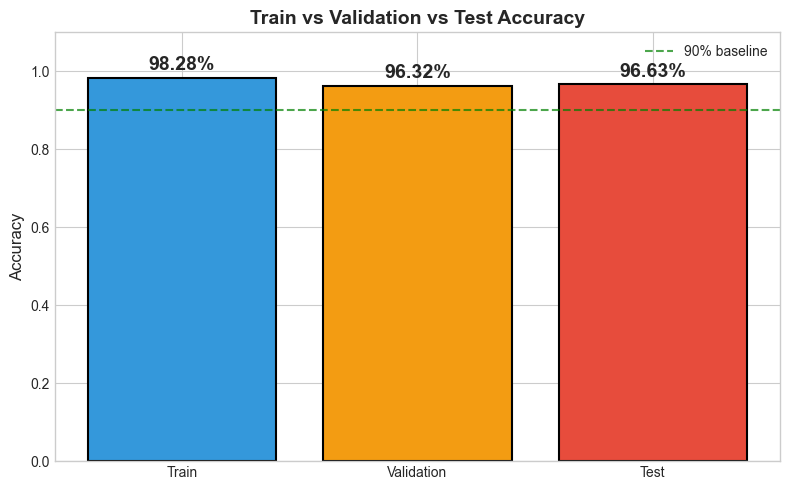


[OK] NO SIGNIFICANT OVERFITTING.


In [11]:
# --- Overfitting Check ---
train_acc = accuracy_score(y_train, (xgb_model.predict_proba(X_train)[:, 1] >= optimal_threshold).astype(int))
val_acc = accuracy_score(y_val, (xgb_model.predict_proba(X_val)[:, 1] >= optimal_threshold).astype(int))
test_acc = accuracy_score(y_test, y_pred_optimized)

print(f"{'='*50}")
print(f"OVERFITTING CHECK (threshold={optimal_threshold:.4f})")
print(f"{'='*50}")
print(f"Train Accuracy:      {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Test Accuracy:       {test_acc * 100:.2f}%")
print(f"Train-Test Gap:      {(train_acc - test_acc) * 100:.2f}%")
print(f"{'='*50}")

fig, ax = plt.subplots(figsize=(8, 5))
acc_labels = ['Train', 'Validation', 'Test']
acc_values = [train_acc, val_acc, test_acc]
bars = ax.bar(acc_labels, acc_values, color=['#3498db', '#f39c12', '#e74c3c'],
              edgecolor='black', linewidth=1.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Validation vs Test Accuracy', fontsize=14, fontweight='bold')
for bar, val in zip(bars, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2%}', ha='center', fontsize=14, fontweight='bold')
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.7, label='90% baseline')
ax.legend()
plt.tight_layout()
plt.show()

gap = train_acc - test_acc
if gap > 0.10:
    print("\n[WARNING] HIGH OVERFITTING DETECTED!")
elif gap > 0.05:
    print("\n[CAUTION] SLIGHT OVERFITTING detected.")
else:
    print("\n[OK] NO SIGNIFICANT OVERFITTING.")

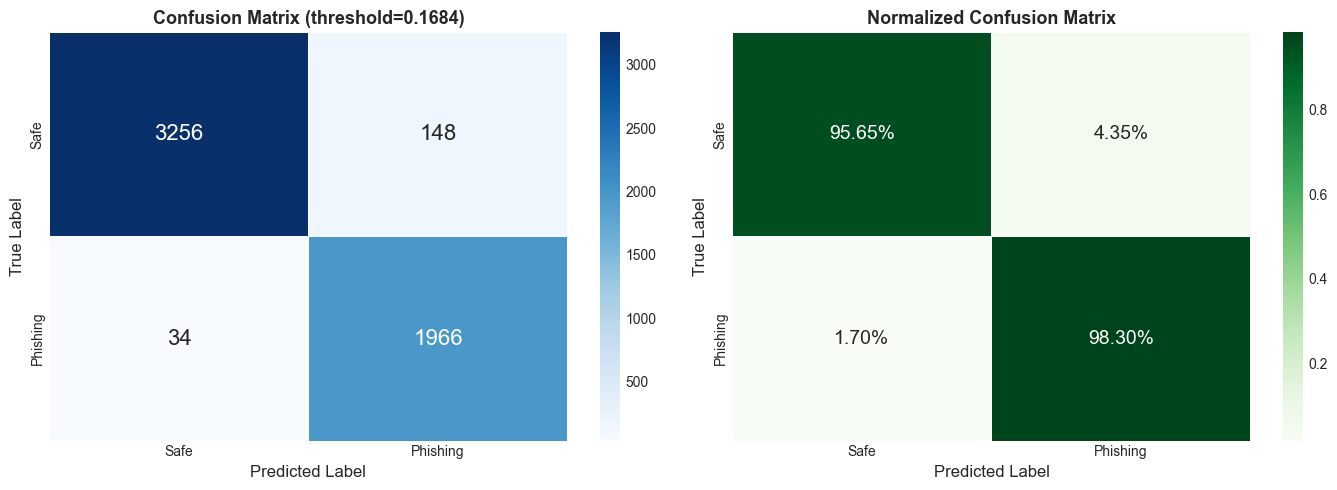


Explicit FPR = FP / (FP + TN) = 148 / (148 + 3256) = 4.3478%


In [12]:
# --- Confusion Matrix (Optimized Threshold) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
            annot_kws={'size': 16}, linewidths=0.5)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title(f'Confusion Matrix (threshold={optimal_threshold:.4f})', fontsize=13, fontweight='bold')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
            annot_kws={'size': 14}, linewidths=0.5)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Normalized Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Explicit FPR calculation
tn, fp, fn, tp = cm.ravel()
fpr_explicit = fp / (fp + tn)
print(f"\nExplicit FPR = FP / (FP + TN) = {fp} / ({fp} + {tn}) = {fpr_explicit*100:.4f}%")

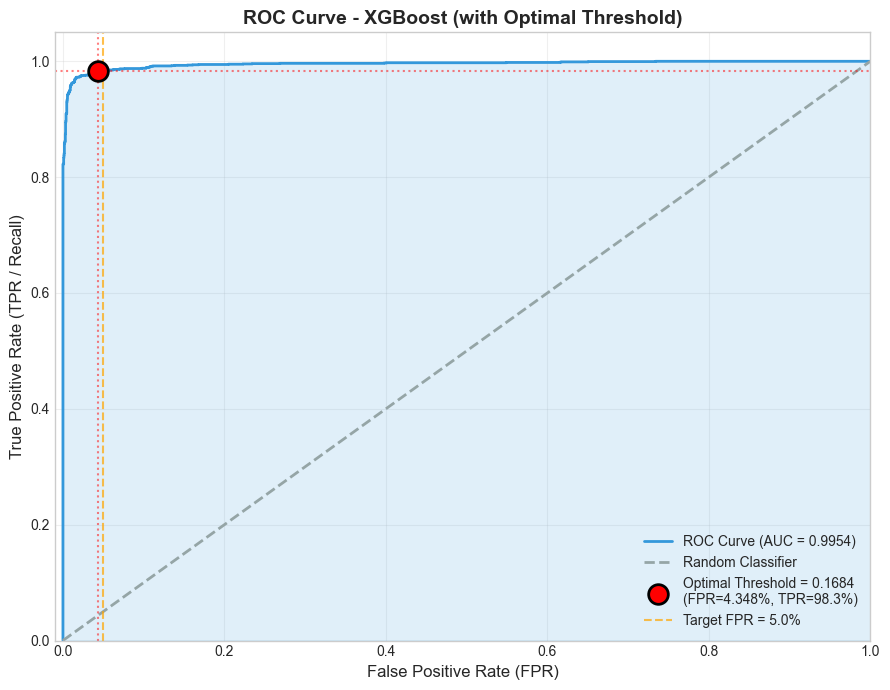

AUC Score: 0.9954


In [13]:
# --- ROC Curve with Optimal Threshold Highlighted ---
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(9, 7))
plt.plot(fpr_curve, tpr_curve, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#95a5a6', lw=2, linestyle='--', label='Random Classifier')
plt.fill_between(fpr_curve, tpr_curve, alpha=0.15, color='#3498db')

# Highlight the optimal threshold point
plt.scatter([achieved_fpr], [achieved_tpr], color='red', s=200, zorder=5, edgecolors='black', linewidth=2,
            label=f'Optimal Threshold = {optimal_threshold:.4f}\n(FPR={achieved_fpr*100:.3f}%, TPR={achieved_tpr*100:.1f}%)')

# Draw lines to the point
plt.axvline(x=achieved_fpr, color='red', linestyle=':', alpha=0.5)
plt.axhline(y=achieved_tpr, color='red', linestyle=':', alpha=0.5)

# Draw target FPR line
plt.axvline(x=TARGET_FPR, color='orange', linestyle='--', alpha=0.7, label=f'Target FPR = {TARGET_FPR*100:.1f}%')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('ROC Curve - XGBoost (with Optimal Threshold)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

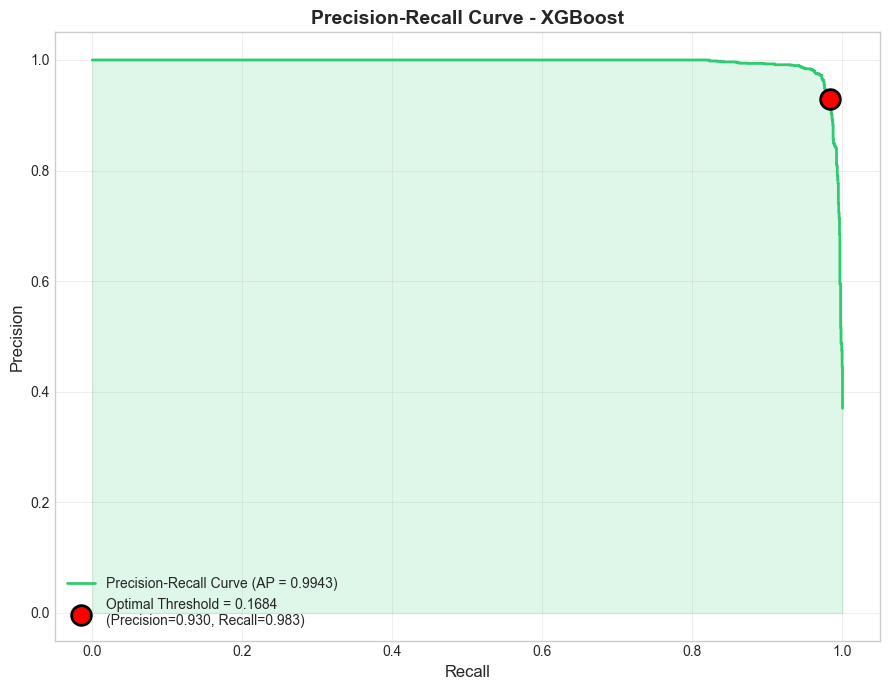

Average Precision Score: 0.9943


In [14]:
# --- Precision-Recall Curve ---
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(9, 7))
plt.plot(recall_curve, precision_curve, color='#2ecc71', lw=2,
         label=f'Precision-Recall Curve (AP = {avg_precision:.4f})')
plt.fill_between(recall_curve, precision_curve, alpha=0.15, color='#2ecc71')

# Find and plot the point for the optimal threshold
opt_precision = precision_score(y_test, y_pred_optimized, zero_division=0)
opt_recall = recall_score(y_test, y_pred_optimized)
plt.scatter([opt_recall], [opt_precision], color='red', s=200, zorder=5,
            edgecolors='black', linewidth=2,
            label=f'Optimal Threshold = {optimal_threshold:.4f}\n(Precision={opt_precision:.3f}, Recall={opt_recall:.3f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")

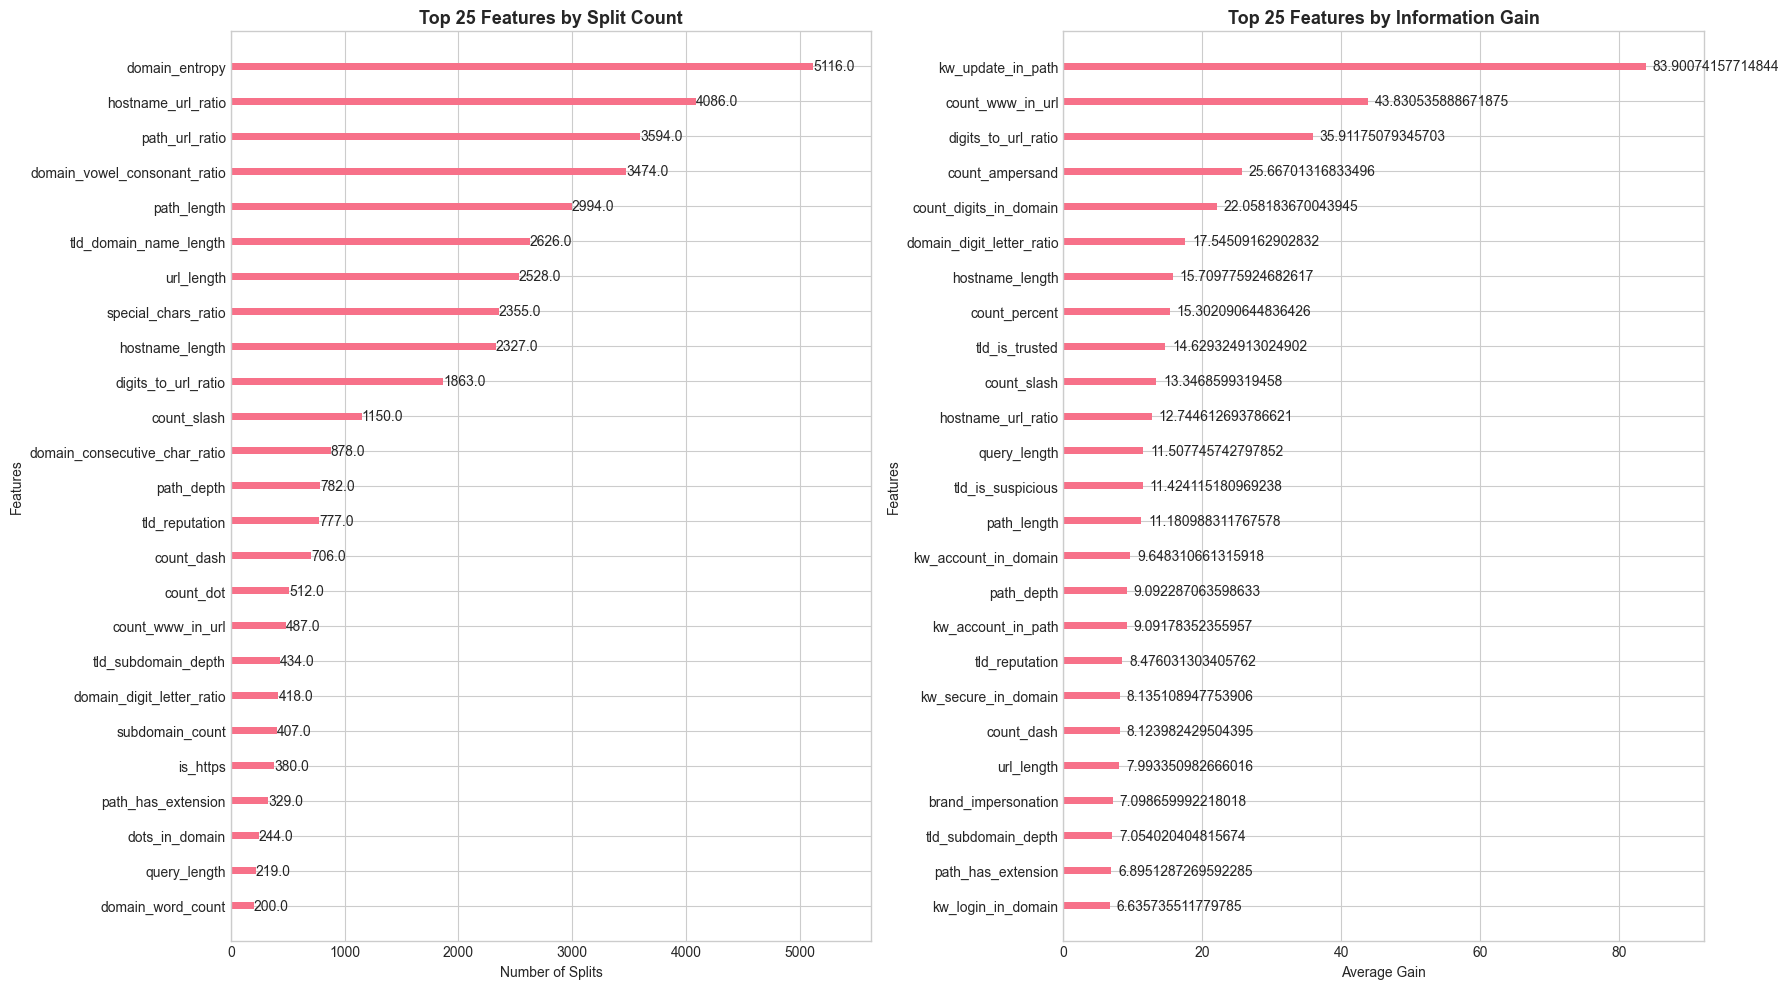


Top 10 Features by Gain:
  1. kw_update_in_path: 83.9007
  2. count_www_in_url: 43.8305
  3. digits_to_url_ratio: 35.9118
  4. count_ampersand: 25.6670
  5. count_digits_in_domain: 22.0582
  6. domain_digit_letter_ratio: 17.5451
  7. hostname_length: 15.7098
  8. count_percent: 15.3021
  9. tld_is_trusted: 14.6293
  10. count_slash: 13.3469


In [15]:
# --- Feature Importance (XGBoost Native) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Plot 1: Weight (number of times feature used in splits)
plot_importance(xgb_model, ax=axes[0], importance_type='weight', max_num_features=25,
                title='Feature Importance (Weight)', xlabel='Number of Splits')
axes[0].set_title('Top 25 Features by Split Count', fontsize=13, fontweight='bold')

# Plot 2: Gain (average improvement in loss)
plot_importance(xgb_model, ax=axes[1], importance_type='gain', max_num_features=25,
                title='Feature Importance (Gain)', xlabel='Average Gain')
axes[1].set_title('Top 25 Features by Information Gain', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 10 features by gain
print("\nTop 10 Features by Gain:")
booster = xgb_model.get_booster()
importance_gain = booster.get_score(importance_type='gain')
sorted_gain = sorted(importance_gain.items(), key=lambda x: x[1], reverse=True)
for i, (feat, gain) in enumerate(sorted_gain[:10]):
    print(f"  {i+1}. {feat}: {gain:.4f}")

CLASSIFICATION REPORT (threshold=0.1684)
              precision    recall  f1-score   support

        Safe       0.99      0.96      0.97      3404
    Phishing       0.93      0.98      0.96      2000

    accuracy                           0.97      5404
   macro avg       0.96      0.97      0.96      5404
weighted avg       0.97      0.97      0.97      5404



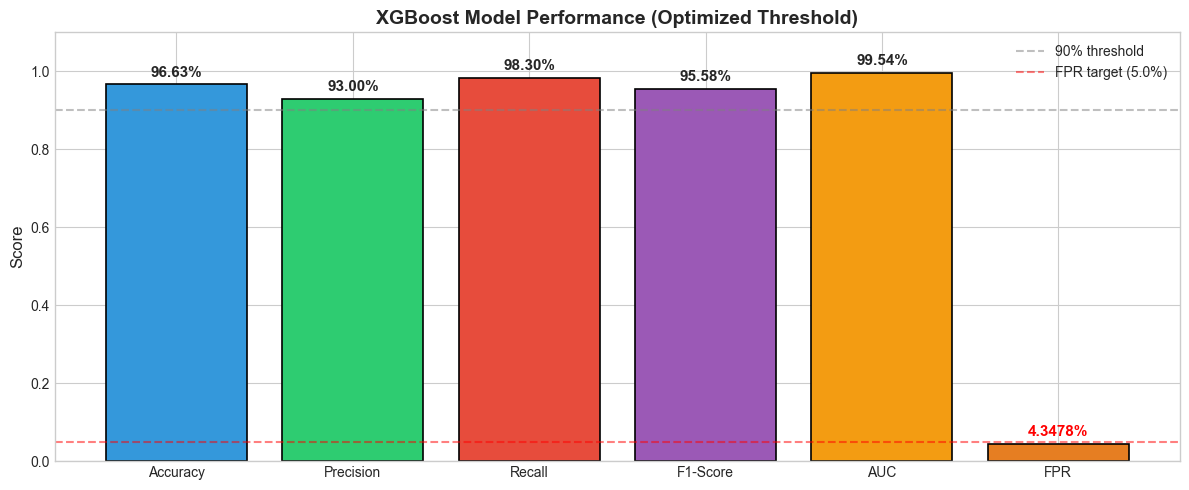

In [16]:
# --- Classification Report ---
print("=" * 60)
print(f"CLASSIFICATION REPORT (threshold={optimal_threshold:.4f})")
print("=" * 60)
print(classification_report(y_test, y_pred_optimized, target_names=['Safe', 'Phishing']))

# Metrics Summary
prec = precision_score(y_test, y_pred_optimized, zero_division=0)
rec = recall_score(y_test, y_pred_optimized)
f1 = f1_score(y_test, y_pred_optimized)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC', 'FPR']
values = [test_acc, prec, rec, f1, roc_auc, fpr_optimized]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#e67e22']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('XGBoost Model Performance (Optimized Threshold)', fontsize=14, fontweight='bold')

for bar, val, name in zip(bars, values, metrics):
    if name == 'FPR':
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4%}', ha='center', fontsize=11, fontweight='bold', color='red')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2%}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
ax.axhline(y=TARGET_FPR, color='red', linestyle='--', alpha=0.5, label=f'FPR target ({TARGET_FPR*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# --- Save XGBoost Model + Optimal Threshold ---
model_data = {
    'model': xgb_model,
    'optimal_threshold': optimal_threshold,
    'target_fpr': TARGET_FPR,
    'achieved_fpr': achieved_fpr,
    'feature_names': X.columns.tolist(),
    'best_iteration': best_iteration,
}

joblib.dump(model_data, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")
print(f"  - Includes optimal threshold: {optimal_threshold:.4f}")
print(f"  - Target FPR: < {TARGET_FPR*100:.2f}%")
print(f"  - Usage: data = joblib.load(path)")
print(f"           model = data['model']")
print(f"           threshold = data['optimal_threshold']")
print(f"           y_pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)")

Model saved to: d:\project-3\src\models\saved_models\url_xgboost.pkl
  - Includes optimal threshold: 0.1684
  - Target FPR: < 5.00%
  - Usage: data = joblib.load(path)
           model = data['model']
           threshold = data['optimal_threshold']
           y_pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
